# 01 — Exploratory Data Analysis

This notebook is the single source of truth for understanding the raw Amazon Reviews data before preprocessing or modelling. It inspects schema, class imbalance, missing values, duplicates, review length, text quality, and product metadata. No processed dataset is created here.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
TRAIN_PATH = RAW_DATA_DIR / 'train_data.csv'
TEST_PATH = RAW_DATA_DIR / 'test_data.csv'
PRODUCT_PATH = RAW_DATA_DIR / 'title_brand.csv'

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
TRAIN_PATH

WindowsPath('D:/Quera/Exercises/amazon-review-sentiment-analysis/data/raw/train_data.csv')

## Load raw datasets

In [2]:
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)
product_df = pd.read_csv(PRODUCT_PATH, low_memory=False)

pd.DataFrame({
    'dataset': ['train', 'test', 'product_metadata'],
    'rows': [len(train_df), len(test_df), len(product_df)],
    'columns': [train_df.shape[1], test_df.shape[1], product_df.shape[1]],
})

,dataset,rows,columns
0,train,838944,11
1,test,20000,10
2,product_metadata,786445,3


In [3]:
display(train_df.head(3))
display(test_df.head(3))
display(product_df.head(3))
print('Train columns:', train_df.columns.tolist())
print('Test columns:', test_df.columns.tolist())
print('Product columns:', product_df.columns.tolist())

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000


,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,NaN,True,2018-06-04,A20GGWE66JW9X2,B006Z394GM,{'Color:': ' FPS01-C'},Brian C Toner,The name and description of this device are mi...,The prize for most useless invention of all ti...,1528070400
1,NaN,True,2018-02-18,ARYJWXHEYHG9M,B005BE058W,"{'Size:': ' 1000W', 'Style:': ' G2'}",Snake,One of the molex connectors on the power suppl...,MELTED MOLEX CONNECTOR,1518912000
2,NaN,True,2018-01-20,A10LHZ7WFZ7HLL,B01DA0YCNC,NaN,Amazon Customer,Remote constantly disconnects/ Roku player fre...,Bricked on the regular,1516406400


,asin,title,brand
0,0011300000,Genuine Geovision 1 Channel 3rd Party NVR IP S...,GeoVision
1,0043396828,"Books ""Handbook of Astronomical Image Processi...",33 Books Co.
2,0060009810,One Hot Summer,Visit Amazon's Carolina Garcia Aguilera Page


Train columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']
Test columns: ['vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']
Product columns: ['asin', 'title', 'brand']


## Target distribution and imbalance

,count,percentage
overall,,
1,82950,9.89
2,56756,6.77
3,81239,9.68
4,156514,18.66
5,461485,55.01


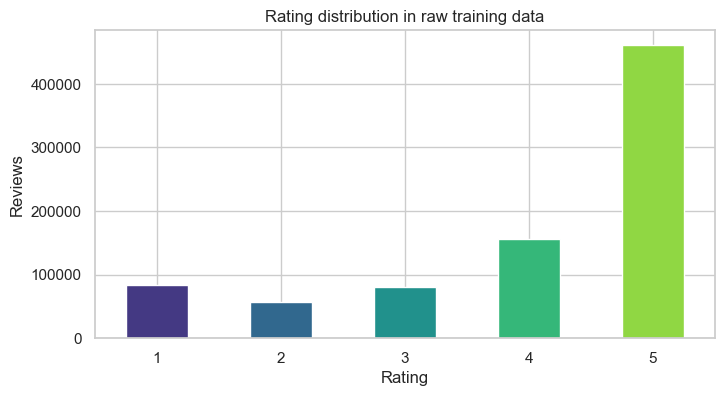

In [4]:
target_counts = train_df['overall'].value_counts().sort_index()
target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': (target_counts / len(train_df) * 100).round(2),
})
display(target_summary)

ax = target_counts.plot(kind='bar', color=sns.color_palette('viridis', 5), figsize=(8, 4))
ax.set(title='Rating distribution in raw training data', xlabel='Rating', ylabel='Reviews')
ax.tick_params(axis='x', rotation=0)
plt.show()

## Missing values and duplicates

In [5]:
missing_summary = pd.DataFrame({
    'missing_count': train_df.isna().sum(),
    'missing_percentage': (train_df.isna().mean() * 100).round(2),
}).sort_values('missing_count', ascending=False)
display(missing_summary)

print('Exact duplicate rows:', int(train_df.duplicated().sum()))
print('Duplicate reviewText values:', int(train_df['reviewText'].duplicated().sum()))
print('Missing reviewText values:', int(train_df['reviewText'].isna().sum()))

,missing_count,missing_percentage
vote,647476,77.18
style,348331,41.52
reviewerName,227,0.03
summary,76,0.01
overall,0,0.00
verified,0,0.00
reviewTime,0,0.00
asin,0,0.00
reviewerID,0,0.00
reviewText,0,0.00


Exact duplicate rows: 8327
Duplicate reviewText values: 31333
Missing reviewText values: 0


## Review-length analysis

,characters
count,838944.000000
mean,624.687384
std,684.129474
min,200.000000
50%,408.000000
90%,1217.000000
95%,1733.000000
99%,3399.000000
99.5%,4357.000000
99.9%,7224.114000


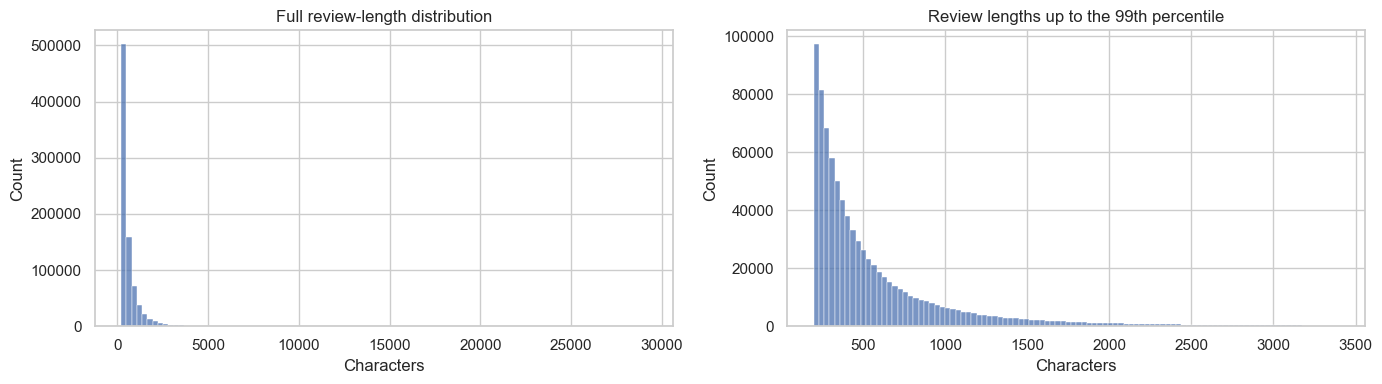

In [6]:
review_text = train_df['reviewText'].fillna('').astype(str)
review_length = review_text.str.len()
display(review_length.describe(percentiles=[0.50, 0.90, 0.95, 0.99, 0.995, 0.999]).to_frame('characters'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(review_length, bins=100, ax=axes[0])
axes[0].set(title='Full review-length distribution', xlabel='Characters')
upper_99 = review_length.quantile(0.99)
sns.histplot(review_length[review_length <= upper_99], bins=100, ax=axes[1])
axes[1].set(title='Review lengths up to the 99th percentile', xlabel='Characters')
plt.tight_layout()
plt.show()

## Text-quality checks relevant to BERT-family models

In [7]:
html_pattern = re.compile(r'<[^>]+>')
url_pattern = re.compile(r'https?://\S+|www\.\S+', flags=re.IGNORECASE)

text_quality = pd.Series({
    'empty_or_whitespace': int(review_text.str.strip().eq('').sum()),
    'contains_possible_html': int(review_text.str.contains(html_pattern, na=False).sum()),
    'contains_url': int(review_text.str.contains(url_pattern, na=False).sum()),
    'contains_line_break': int(review_text.str.contains(r'[\r\n]', regex=True, na=False).sum()),
}, name='row_count')
text_quality.to_frame()

,row_count
empty_or_whitespace,0
contains_possible_html,17130
contains_url,9470
contains_line_break,297714


## Product and brand coverage

In [8]:
metadata_unique = product_df.drop_duplicates(subset='asin')
metadata_coverage = train_df['asin'].isin(metadata_unique['asin']).mean()
print(f'ASIN metadata coverage: {metadata_coverage:.2%}')

brand_summary = (
    train_df[['asin', 'overall']]
    .merge(metadata_unique[['asin', 'brand']], on='asin', how='left')
    .groupby('brand', dropna=False)
    .agg(review_count=('overall', 'size'), average_rating=('overall', 'mean'))
    .sort_values('review_count', ascending=False)
    .head(10)
)
brand_summary['average_rating'] = brand_summary['average_rating'].round(3)
brand_summary

ASIN metadata coverage: 99.99%


,review_count,average_rating
brand,,
Logitech,16993,3.952
Samsung,15406,3.941
AmazonBasics,13213,4.201
Asus,11928,3.856
Sony,11752,3.921
Anker,9860,4.244
TP-LINK,9773,3.929
SanDisk,8389,3.959
Sabrent,7309,4.027


## EDA conclusions

- The task is five-class rating prediction (`1..5`) from `reviewText`.
- The raw target is strongly imbalanced, especially toward rating 5.
- Exact duplicate rows must be removed before sampling and splitting.
- Reviews have a strongly right-skewed length distribution.
- Transformer preprocessing should remain light: remove HTML/URLs and normalize whitespace while preserving case, punctuation, sentence structure, stopwords, and negation.
- The untouched official test set is reserved only for final inference.